<a href="https://colab.research.google.com/github/aman-healthdata/health-disease-risk/blob/main/COVID19_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import Libraries & Load Dataset

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")  # Nice plot style

# Load global COVID-19 dataset from Our World in Data
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
covid = pd.read_csv(url)

# Preview the first 5 rows
covid.head()


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


🔹 Step 2: Filter for the United Kingdom

In [2]:
# Filter dataset for the United Kingdom
uk = covid[covid['location'] == 'United Kingdom'].copy()

# Convert 'date' column to datetime type and set as index
uk['date'] = pd.to_datetime(uk['date'])
uk.set_index('date', inplace=True)

# Preview the relevant columns
uk[['new_cases', 'new_deaths']].tail()


,new_cases,new_deaths
date,,
2024-07-31,0.0,0.0
2024-08-01,0.0,0.0
2024-08-02,0.0,0.0
2024-08-03,0.0,0.0
2024-08-04,3400.0,0.0


Step 3: Plot Daily Cases and Deaths

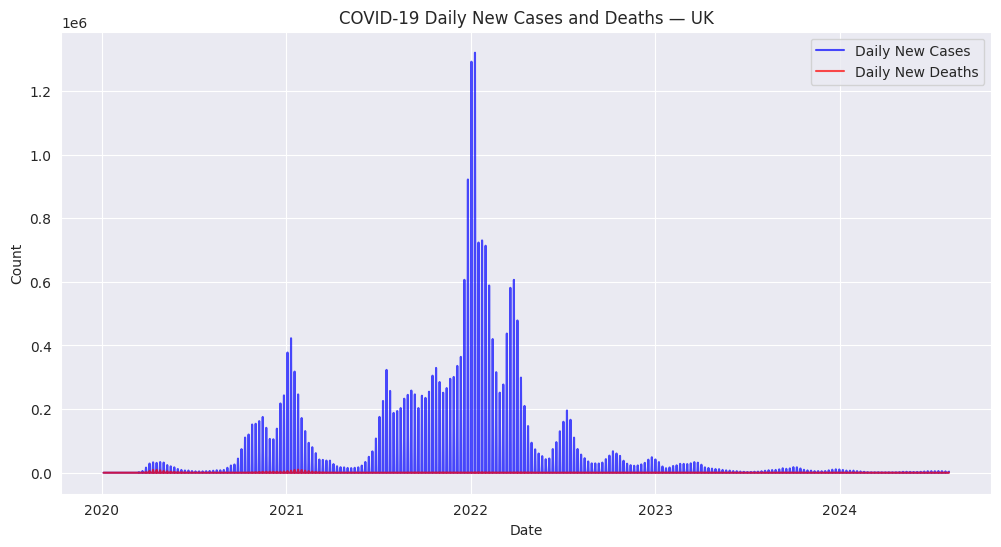

In [3]:
# Plot daily new cases and new deaths
plt.figure(figsize=(12,6))
plt.plot(uk.index, uk['new_cases'], label='Daily New Cases', color='blue', alpha=0.7)
plt.plot(uk.index, uk['new_deaths'], label='Daily New Deaths', color='red', alpha=0.7)
plt.title("COVID-19 Daily New Cases and Deaths — UK")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.show()


Step 4: Add 7-Day Moving Average

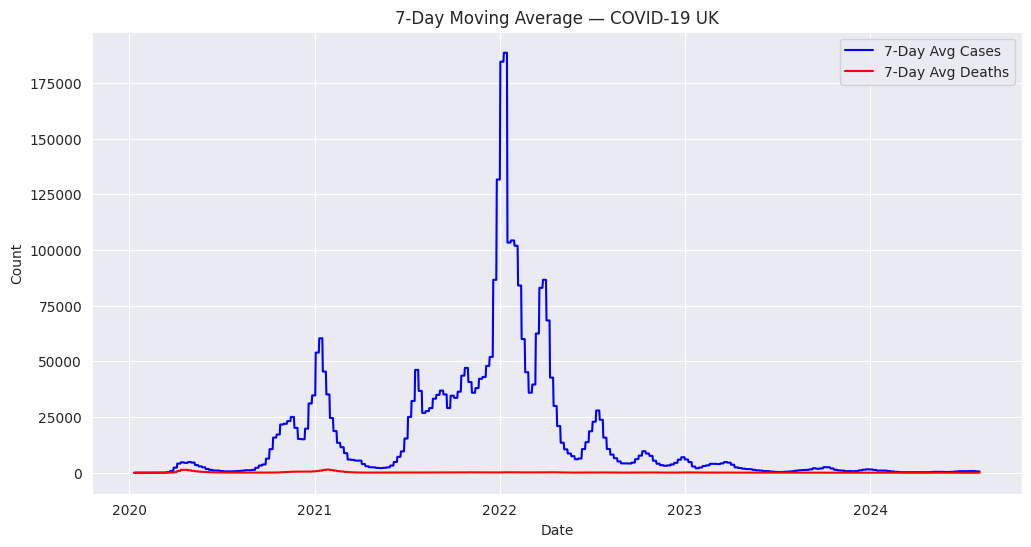

In [4]:
# Calculate 7-day moving averages
uk['cases_ma7'] = uk['new_cases'].rolling(7).mean()
uk['deaths_ma7'] = uk['new_deaths'].rolling(7).mean()

# Plot 7-day moving averages
plt.figure(figsize=(12,6))
plt.plot(uk.index, uk['cases_ma7'], label='7-Day Avg Cases', color='blue')
plt.plot(uk.index, uk['deaths_ma7'], label='7-Day Avg Deaths', color='red')
plt.title("7-Day Moving Average — COVID-19 UK")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.show()


🔹 Step 5: Analyze Key Trends
1️⃣ Identify Peaks in Cases and Deaths

In [5]:
# Find date of maximum daily cases and deaths
max_cases_date = uk['new_cases'].idxmax()
max_cases_value = uk['new_cases'].max()

max_deaths_date = uk['new_deaths'].idxmax()
max_deaths_value = uk['new_deaths'].max()

print(f"Peak daily cases: {max_cases_value} on {max_cases_date.date()}")
print(f"Peak daily deaths: {max_deaths_value} on {max_deaths_date.date()}")


Peak daily cases: 1320332.0 on 2022-01-09
Peak daily deaths: 9723.0 on 2021-01-24


2️⃣ Basic Summary Statistics

In [6]:
summary = uk[['new_cases','new_deaths']].describe()
summary


,new_cases,new_deaths
count,1.674000e+03,1674.000000
mean,1.491913e+04,138.657109
std,7.976122e+04,727.407268
min,0.000000e+00,0.000000
25%,0.000000e+00,0.000000
50%,0.000000e+00,0.000000
75%,0.000000e+00,0.000000
max,1.320332e+06,9723.000000


Weekly Percent Change

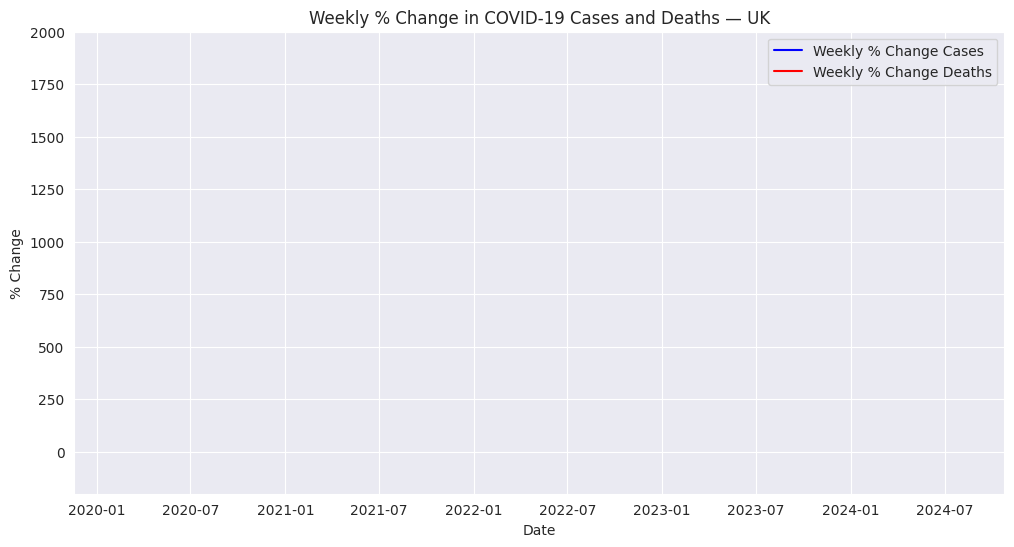

In [7]:
uk['cases_pct_change'] = uk['new_cases'].pct_change(7) * 100
uk['deaths_pct_change'] = uk['new_deaths'].pct_change(7) * 100

plt.figure(figsize=(12,6))
plt.plot(uk.index, uk['cases_pct_change'], label='Weekly % Change Cases', color='blue')
plt.plot(uk.index, uk['deaths_pct_change'], label='Weekly % Change Deaths', color='red')
plt.title("Weekly % Change in COVID-19 Cases and Deaths — UK")
plt.xlabel("Date")
plt.ylabel("% Change")
plt.legend()
plt.show()
